# 04 趋势建模分析

## 目标
- 时间序列分析：用户行为的日/周趋势
- 用户留存分析（Cohort Analysis）
- 使用线性回归进行趋势预测
- 用户生命周期分析

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'user_behavior_clean.csv')
df = pd.read_csv(DATA_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = pd.to_datetime(df['date'])

print(f'数据加载完成: {len(df):,} 条记录')

数据加载完成: 5,070,824 条记录


## 1. 每日行为趋势

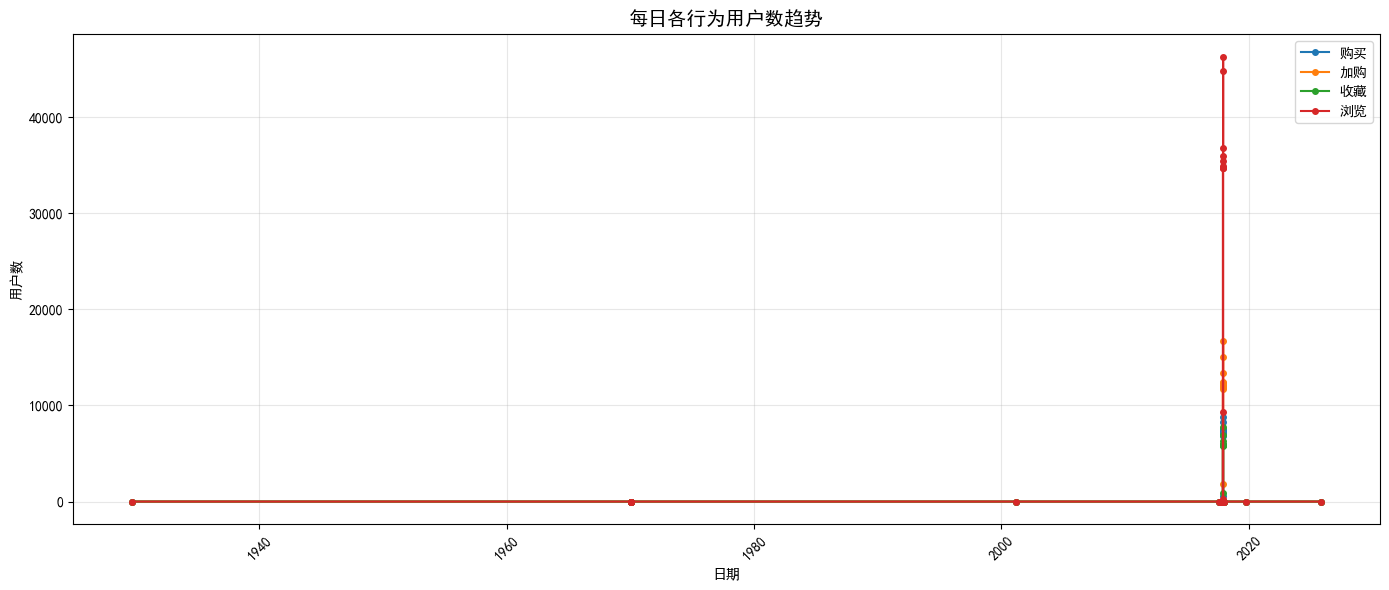

In [2]:
# 每日各行为用户数
daily_users = df.groupby(['date', 'behavior_type'])['user_id'].nunique().unstack(fill_value=0)

behavior_map = {'pv': '浏览', 'cart': '加购', 'fav': '收藏', 'buy': '购买'}
daily_users.columns = [behavior_map.get(c, c) for c in daily_users.columns]

fig, ax = plt.subplots(figsize=(14, 6))
for col in daily_users.columns:
    ax.plot(daily_users.index, daily_users[col], marker='o', markersize=4, label=col)

ax.set_title('每日各行为用户数趋势', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('用户数')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'daily_trend.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 2. 星期几的行为分布

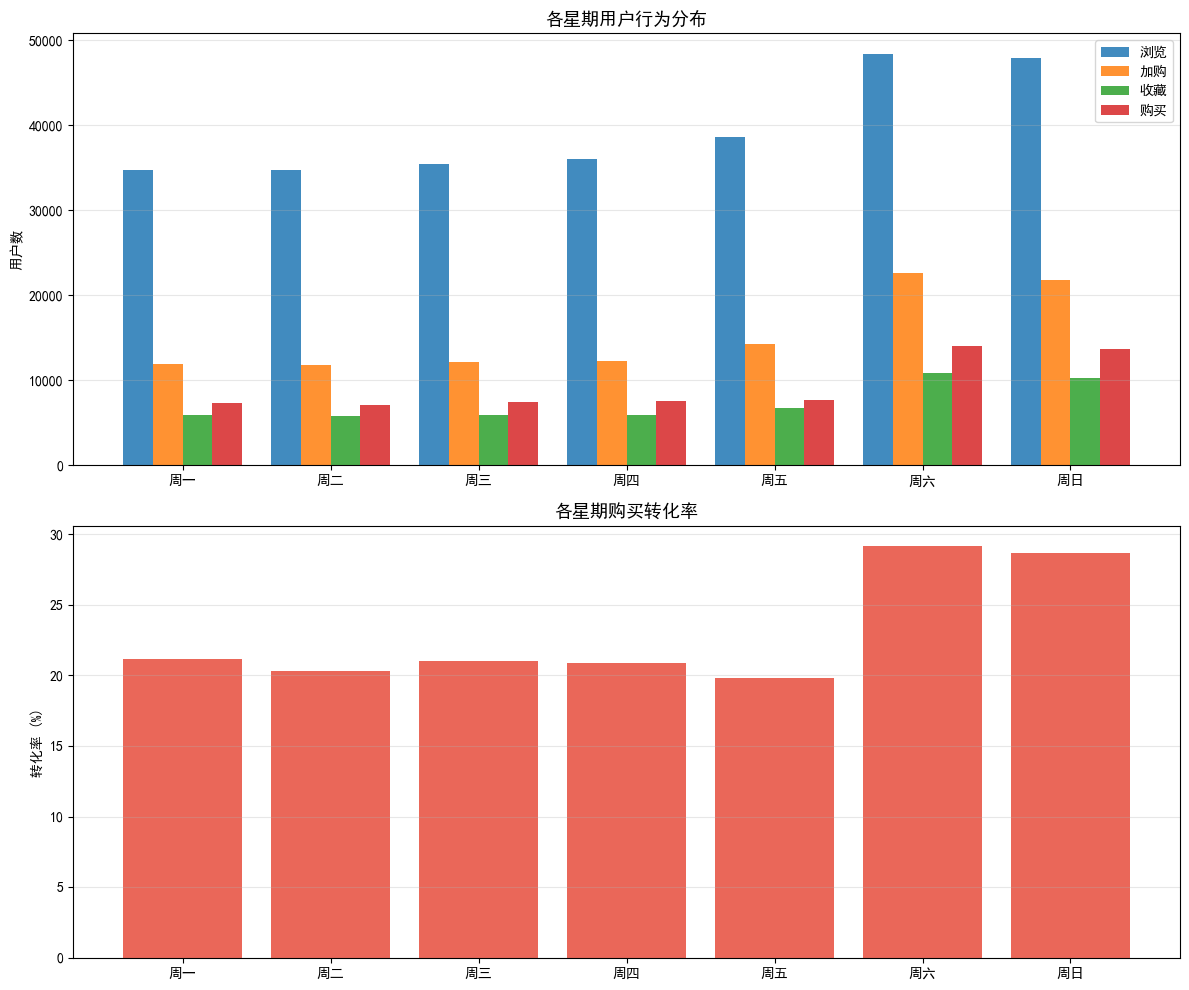

In [3]:
# 添加星期信息
df['weekday'] = df['datetime'].dt.weekday
weekday_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']

# 按星期统计
weekday_stats = df.groupby(['weekday', 'behavior_type'])['user_id'].nunique().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 各行为按星期分布
x = range(7)
width = 0.2
for i, (bt, name) in enumerate(behavior_map.items()):
    if bt in weekday_stats.columns:
        axes[0].bar([xi + i*width for xi in x], weekday_stats[bt], width, label=name, alpha=0.85)

axes[0].set_xticks([xi + 1.5*width for xi in x])
axes[0].set_xticklabels(weekday_names)
axes[0].set_title('各星期用户行为分布', fontsize=13, fontweight='bold')
axes[0].set_ylabel('用户数')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 购买转化率按星期分布
if 'pv' in weekday_stats.columns and 'buy' in weekday_stats.columns:
    conversion_rate = weekday_stats['buy'] / weekday_stats['pv'] * 100
    axes[1].bar(x, conversion_rate, color='#e74c3c', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(weekday_names)
    axes[1].set_title('各星期购买转化率', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('转化率 (%)')
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'weekday_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 3. 用户留存分析（Cohort Analysis）

In [9]:
# Cohort分析：按用户首次购买日期分组，计算日留存
buy_df = df[df['behavior_type'] == 'buy'].copy()

# 获取用户首次购买日期
first_purchase = buy_df.groupby('user_id')['date'].min().reset_index()
first_purchase.columns = ['user_id', 'first_purchase_date']

# 合并
buy_cohort = buy_df.merge(first_purchase, on='user_id')

# 计算天数差
buy_cohort['day_diff'] = (buy_cohort['date'] - buy_cohort['first_purchase_date']).dt.days

# 按首次购买日期分组，统计各天的活跃用户数
cohort_data = buy_cohort.groupby(['first_purchase_date', 'day_diff'])['user_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='first_purchase_date', columns='day_diff', values='user_id')

# 计算留存率
cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# 只保留第0、1、3、7天
retention_cols = [col for col in [0, 1, 2, 3, 4, 5, 6, 7] if col in retention.columns]
retention = retention[retention_cols]

print('=== 用户日留存率矩阵 (%) ===')
print(retention.round(1))

=== 用户日留存率矩阵 (%) ===
day_diff                 0     1     2     3     4     5     6     7
first_purchase_date                                                 
2017-11-24           100.0  30.4  23.2  25.0  25.0  23.6  22.3  24.5
2017-11-25           100.0  23.2  22.0  19.9  20.8  20.9  19.1  23.0
2017-11-26           100.0  22.8  18.8  19.6  18.6  17.6  21.5  20.4
2017-11-27           100.0  19.3  20.1  19.0  17.6  20.9  19.3   NaN
2017-11-28           100.0  19.3  18.0  17.2  19.8  18.3   NaN   NaN
2017-11-29           100.0  18.9  15.7  17.7  17.3   NaN   NaN   NaN
2017-11-30           100.0  17.1  17.9  16.9   NaN   NaN   NaN   NaN
2017-12-01           100.0  20.6  17.7   NaN   NaN   NaN   NaN   NaN
2017-12-02           100.0  17.8   NaN   NaN   NaN   NaN   NaN   NaN
2017-12-03           100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN


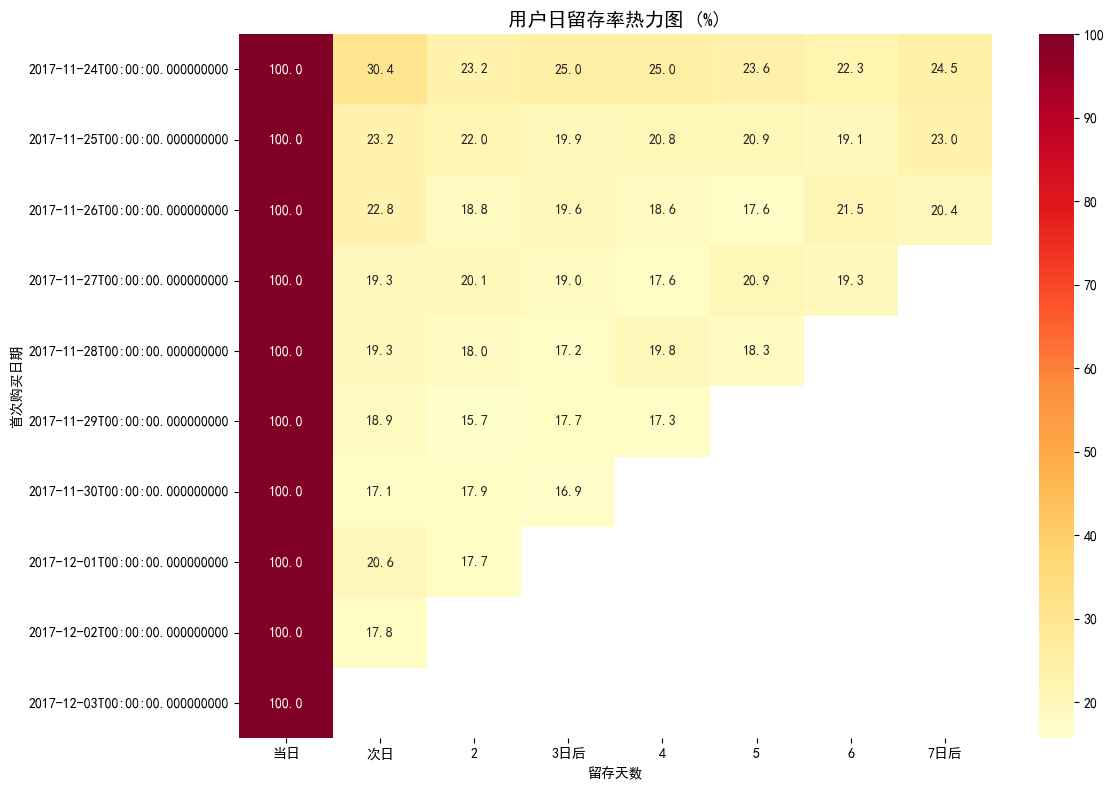

In [10]:
# 绘制留存热力图
fig, ax = plt.subplots(figsize=(12, 8))

# 修改列名
col_names = {0: '当日', 1: '次日', 3: '3日后', 7: '7日后'}
retention_display = retention.rename(columns=col_names)

sns.heatmap(retention_display, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('用户日留存率热力图 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('留存天数')
ax.set_ylabel('首次购买日期')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'cohort_retention.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 4. 趋势预测（线性回归）

In [6]:
# 使用线性回归预测购买用户数趋势
daily_buyers = df[df['behavior_type'] == 'buy'].groupby('date')['user_id'].nunique().reset_index()
daily_buyers.columns = ['date', 'buyers']
daily_buyers['day_num'] = range(len(daily_buyers))

# 训练模型
X = daily_buyers[['day_num']]
y = daily_buyers['buyers']

model = LinearRegression()
model.fit(X, y)

# 预测
y_pred = model.predict(X)

# 评估
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f'线性回归模型评估:')
print(f'  R² Score: {r2:.4f}')
print(f'  MAE: {mae:.2f}')
print(f'  趋势斜率: {model.coef_[0]:.2f} 用户/天')

线性回归模型评估:
  R² Score: 0.4694
  MAE: 1146.18
  趋势斜率: 512.37 用户/天


c:\Users\PC\AppData\Local\Programs\Python\Python37\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  "X does not have valid feature names, but"
c:\Users\PC\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:20: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
c:\Users\PC\AppData\Local\Programs\Python\Python37\lib\site-packages\ipykernel_launcher.py:22: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
c:\Users\PC\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


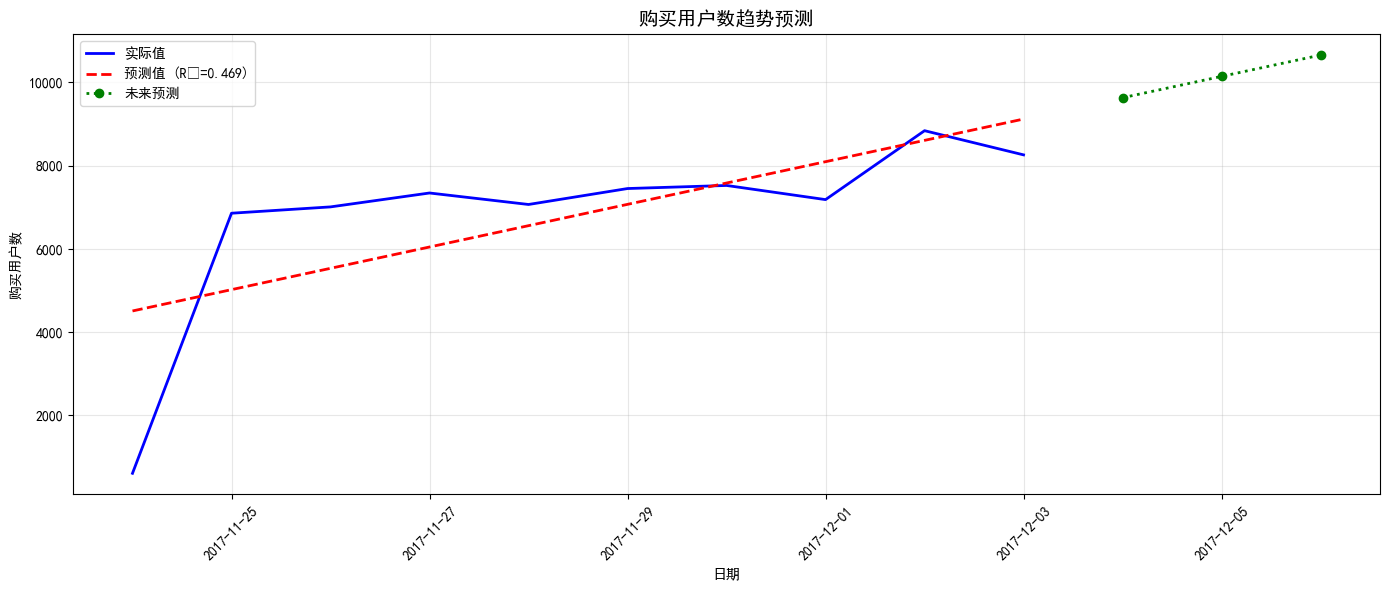

In [7]:
# 可视化预测结果
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_buyers['date'], daily_buyers['buyers'], 'b-', label='实际值', linewidth=2)
ax.plot(daily_buyers['date'], y_pred, 'r--', label=f'预测值 (R²={r2:.3f})', linewidth=2)

# 预测未来3天
future_days = pd.date_range(start=daily_buyers['date'].max(), periods=4)[1:]
future_X = np.array(range(len(daily_buyers), len(daily_buyers) + 3)).reshape(-1, 1)
future_pred = model.predict(future_X)

ax.plot(future_days, future_pred, 'g:', label='未来预测', linewidth=2, marker='o')

ax.set_title('购买用户数趋势预测', fontsize=14, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('购买用户数')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'trend_prediction.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 5. 用户活跃度分析

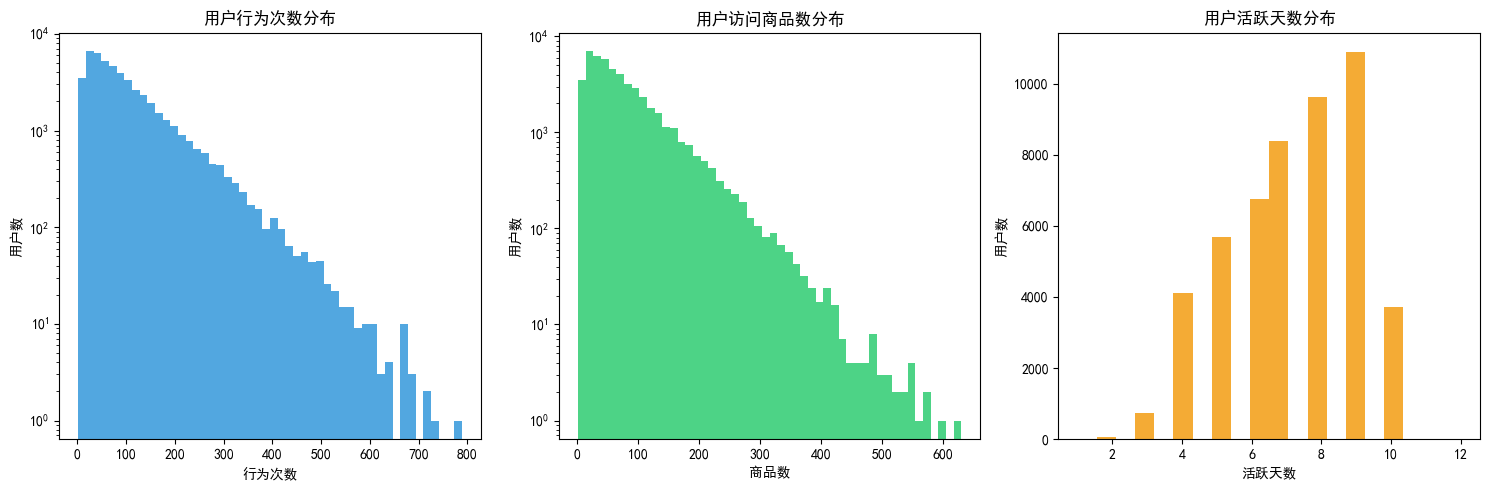

=== 用户活跃度统计 ===
            user_id  total_actions  unique_items  active_days
count  5.000000e+04   50000.000000  50000.000000  50000.00000
mean   5.091275e+05     101.416480     77.038460      7.17838
std    2.936173e+05      86.875815     64.082934      1.81684
min    2.000000e+01       2.000000      2.000000      1.00000
25%    2.558472e+05      39.000000     31.000000      6.00000
50%    5.082115e+05      76.000000     58.000000      7.00000
75%    7.618182e+05     136.000000    103.000000      9.00000
max    1.018011e+06     788.000000    630.000000     12.00000


In [8]:
# 用户行为次数分布
user_activity = df.groupby('user_id').agg(
    total_actions=('behavior_type', 'count'),
    unique_items=('item_id', 'nunique'),
    active_days=('date', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 行为次数分布
axes[0].hist(user_activity['total_actions'], bins=50, color='#3498db', alpha=0.85)
axes[0].set_title('用户行为次数分布', fontsize=12, fontweight='bold')
axes[0].set_xlabel('行为次数')
axes[0].set_ylabel('用户数')
axes[0].set_yscale('log')  # 使用对数刻度

# 访问商品数分布
axes[1].hist(user_activity['unique_items'], bins=50, color='#2ecc71', alpha=0.85)
axes[1].set_title('用户访问商品数分布', fontsize=12, fontweight='bold')
axes[1].set_xlabel('商品数')
axes[1].set_ylabel('用户数')
axes[1].set_yscale('log')

# 活跃天数分布
axes[2].hist(user_activity['active_days'], bins=20, color='#f39c12', alpha=0.85)
axes[2].set_title('用户活跃天数分布', fontsize=12, fontweight='bold')
axes[2].set_xlabel('活跃天数')
axes[2].set_ylabel('用户数')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(os.getcwd()), 'report', 'user_activity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('=== 用户活跃度统计 ===')
print(user_activity.describe())

## 6. 趋势分析总结

### 核心发现
1. **日趋势**：用户行为是否有明显的增长/下降趋势
2. **周规律**：工作日 vs 周末的行为差异
3. **留存情况**：用户留存率随时间的变化
4. **预测结果**：线性模型的预测能力

### 业务建议
- 根据周规律安排营销活动
- 针对留存率下降的时间节点进行干预
- 利用趋势预测进行库存和运营规划